In [1]:
# Imports y notas rápidas:
# - qml: PennyLane (construcción y ejecución de QNodes)
# - np: NumPy estándar (generación de datos)
# - pnp: PennyLane-compatible NumPy (usar cuando los arrays participen en autodiff)
# - tqdm: barras de progreso para bucles largos
# - train_test_split: dividir dataset en entrenamiento/validación
import pennylane as qml
import numpy as np
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import random
import math
import sys
from scipy.stats import truncnorm

In [2]:
from pathlib import Path
import sys

# directorio que contiene model.py
project_root = Path("/home/dayana-henao/Escritorio/DiscriminativeQuantumNeuralNetworks")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# ahora importa el módulo
from model import (
    Circuit, rho1, rho2, loss, get_probabilities,
    get_batches, batch_generator, evaluate_model,
    predict_label, confusion_matrix_inconclusive
)

## Generación de datos (Distribución Uniforme)

In [3]:
# Generación de datos (Distribución uniforme)
# NOTA: aquí se usa 'random.seed' (módulo de Python) pero las muestras se
# generan con 'np.random.uniform' (NumPy). Para reproducibilidad completa
# se fija también la semilla de NumPy además de la del módulo random.

# Test set
random.seed(2)
np.random.seed(2)
n_test = 10000
data_test = []

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)

a_values = sample_truncated_normal(mean=0.25, std=0.05, size=n_test//3)

for a in a_values:
    rho, label = rho1(a)
    data_test.append((rho, label))

b_test = np.random.uniform(0, 1, math.ceil(n_test*(2/3)))
for b in b_test:
    rho, label = rho2(b)
    data_test.append((rho, label))

# Training / validation 
random.seed(90701)
np.random.seed(90701)
n_samples = 50
data = []

def sample_truncated_normal(mean, std, size):
    a, b = (0 - mean) / std, (1 - mean) / std
    return truncnorm(a, b, loc=mean, scale=std).rvs(size)

a_values = sample_truncated_normal(mean=0.25, std=0.05, size=n_samples//3)
for a in a_values:
    rho, label = rho1(a)
    data.append((rho, label))  


b_values = np.random.uniform(0, 1, math.ceil(n_samples*(2/3)))
for b in b_values:
    rho, label = rho2(b)
    data.append((rho, label))

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)


## Definir pesos de pérdida

In [4]:
# Pesos de la pérdida: controlar la penalización por errores e inconclusos
# - alpha_err: cuánto penaliza el clasificador un resultado erróneo
# - alpha_inc: cuánto penaliza un resultado inconcluso
alpha_err = 20
alpha_inc = 2

## Entrenamiento del modelo

In [5]:
# --- 4. ENTRENAMIENTO ROBUSTO CON REINICIOS MÚLTIPLES ---

# Parámetros generales
n_restarts = 5       # Intentaremos 5 veces desde cero
n_iter = 5000        # Iteraciones máximas por intento
batch_size = max(1, int(round(len(data_train) * 0.2)))

# Variables para guardar el mejor modelo global
global_best_val_loss = float('inf')
global_best_params = None
best_history = {} # Para graficar el ganador

print(f"\nIniciando protocolo de {n_restarts} reinicios para escapar de mínimos locales...\n")

for attempt in range(n_restarts):
    print(f"--- INTENTO {attempt + 1}/{n_restarts} ---")
    
    # Semilla única para esta inicialización
    seed_attempt = 90701 + attempt
    np.random.seed(seed_attempt)
    initial_params = np.random.uniform(0, 2 * np.pi, 30)
    params = pnp.array(initial_params, requires_grad=True)
    
    # Optimizador fresco
    opt = qml.AdamOptimizer(stepsize=0.01)
    
    # Variables de control local
    patience = 500
    min_delta = 1e-4
    best_val_loss_local = float('inf')
    best_params_local = params.copy()
    patience_counter = 0
    
    # Scheduler LR
    plateau_patience = 150
    plateau_factor = 0.5
    min_lr = 1e-5
    plateau_counter = 0

    # Historiales locales para este intento
    loc_loss, loc_val_loss = [], []
    loc_train_suc, loc_train_err, loc_train_inc = [], [], []
    loc_val_suc, loc_val_err, loc_val_inc = [], [], []
    
    # Generador de datos
    rng_attempt = np.random.default_rng(seed_attempt)
    gen = batch_generator(data_train, batch_size, rng_attempt)
    
    # Bucle de entrenamiento
    for it in tqdm(range(n_iter), desc=f"Entrenando intento {attempt+1}", leave=False):
        batch = next(gen)
        
        # Paso de optimización
        params, train_loss = opt.step_and_cost(lambda v: loss(v, batch, alpha_err, alpha_inc), params)
        
        # Validación
        val_loss = loss(params, data_val, alpha_err, alpha_inc)
        
        # Evaluación de métricas
        suc_train, err_train, inc_train = evaluate_model(params, data_train)
        suc_val, err_val, inc_val = evaluate_model(params, data_val)

        # Guardar historial local
        loc_loss.append(train_loss)
        loc_val_loss.append(val_loss)
        
        loc_train_suc.append(suc_train)
        loc_train_err.append(err_train)
        loc_train_inc.append(inc_train)
        
        loc_val_suc.append(suc_val)
        loc_val_err.append(err_val)
        loc_val_inc.append(inc_val)
        
        # Early Stopping & Best Model Save
        if val_loss < best_val_loss_local - min_delta:
            best_val_loss_local = val_loss
            best_params_local = params.copy()
            patience_counter = 0
            plateau_counter = 0
        else:
            patience_counter += 1
            plateau_counter += 1
            
        # LR Reduction
        if plateau_counter >= plateau_patience:
            new_lr = max(opt.stepsize * plateau_factor, min_lr)
            if new_lr < opt.stepsize:
                opt.stepsize = new_lr
                plateau_counter = 0 # Reset tras cambiar LR
        
        if patience_counter >= patience:
            break
    
    # Evaluación rápida del resultado de este intento
    print(f" Fin Intento {attempt+1}: Mejor Val Loss = {best_val_loss_local:.6f}")
    
    # Comparar con el mejor global
    if best_val_loss_local < global_best_val_loss:
        print(f"  ¡NUEVO RÉCORD! Mejora de {global_best_val_loss:.6f} a {best_val_loss_local:.6f}")
        global_best_val_loss = best_val_loss_local
        global_best_params = best_params_local.copy()
        
        # Guardamos el historial completo del ganador
        best_history = {
            'loss': loc_loss,
            'val_loss': loc_val_loss,
            'train_suc': loc_train_suc,
            'train_err': loc_train_err,
            'train_inc': loc_train_inc,
            'val_suc': loc_val_suc,
            'val_err': loc_val_err,
            'val_inc': loc_val_inc
        }
    else:
        print(f"  No superó el récord actual.")
    print("-" * 40)

# --- 5. RESULTADOS FINALES ---
print("\nRecuperando el MEJOR modelo de todos los intentos...")
params = global_best_params

# Restaurar historiales globales para que funcionen las celdas de visualización siguientes
# (Esto corrige que "loss_history is not defined")
loss_history = best_history['loss']
val_loss_history = best_history['val_loss']
train_suc_history = best_history['train_suc']
train_err_history = best_history['train_err']
train_inc_history = best_history['train_inc']
val_suc_history = best_history['val_suc']
val_err_history = best_history['val_err']
val_inc_history = best_history['val_inc']

print("\nResultados finales en el conjunto de prueba:")
test_suc, test_err, test_inc = evaluate_model(params, data_test)
print(f"  Éxito promedio      = {test_suc:.4f}")
print(f"  Error promedio      = {test_err:.4f}")
print(f"  Inconcluso promedio = {test_inc:.4f}")


Iniciando protocolo de 5 reinicios para escapar de mínimos locales...

--- INTENTO 1/5 ---


Entrenando intento 1:   0%|          | 0/5000 [00:00<?, ?it/s]

 Fin Intento 1: Mejor Val Loss = 0.640822
  ¡NUEVO RÉCORD! Mejora de inf a 0.640822
----------------------------------------
--- INTENTO 2/5 ---


 Fin Intento 2: Mejor Val Loss = 2.240910
  No superó el récord actual.
----------------------------------------
--- INTENTO 3/5 ---


 Fin Intento 3: Mejor Val Loss = 0.641486
  No superó el récord actual.
----------------------------------------
--- INTENTO 4/5 ---


 Fin Intento 4: Mejor Val Loss = 0.928657
  No superó el récord actual.
----------------------------------------
--- INTENTO 5/5 ---


 Fin Intento 5: Mejor Val Loss = 0.642391
  No superó el récord actual.
----------------------------------------

Recuperando el MEJOR modelo de todos los intentos...

Resultados finales en el conjunto de prueba:
  Éxito promedio      = 0.7620
  Error promedio      = 0.0002
  Inconcluso promedio = 0.2378


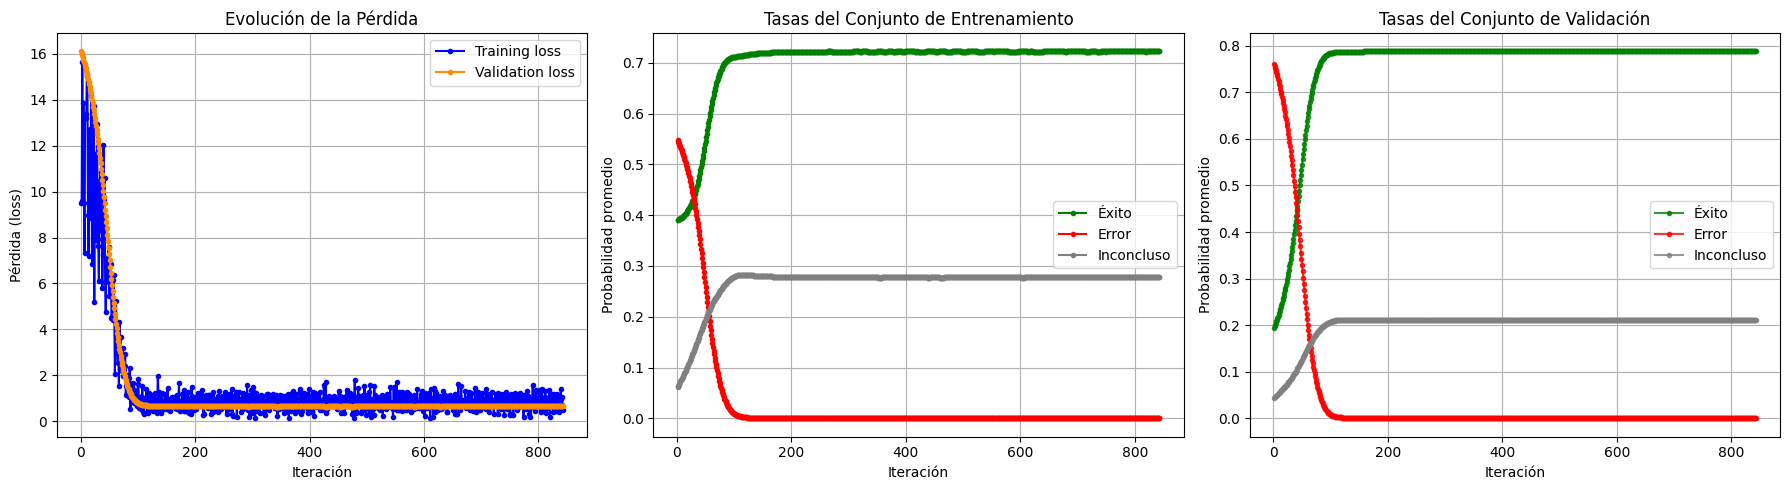

In [6]:
# Visualización de los resultados guardados durante el entrenamiento
# Se muestran: (1) pérdida, (2) tasas en entrenamiento, (3) tasas en validación
it = len(train_suc_history)

# Visualización de los resultados
plt.figure(figsize=(18, 5))

# 1. Evolución de la pérdida
plt.subplot(1, 3, 1)
plt.plot(range(1, it+1), loss_history, '.-', label="Training loss", color='blue')
plt.plot(range(1, it+1), val_loss_history, '.-', label="Validation loss", color='darkorange')
plt.xlabel("Iteración")
plt.ylabel("Pérdida (loss)")
plt.title("Evolución de la Pérdida")
plt.grid(True)
plt.legend()

# 2. Tasas en entrenamiento
plt.subplot(1, 3, 2)
plt.plot(range(1, it+1), train_suc_history, '.-', label="Éxito", color='green')
plt.plot(range(1, it+1), train_err_history, '.-', label="Error", color='red')
plt.plot(range(1, it+1), train_inc_history, '.-', label="Inconcluso", color='gray')
plt.xlabel("Iteración")
plt.ylabel("Probabilidad promedio")
plt.title("Tasas del Conjunto de Entrenamiento")
plt.grid(True)
plt.legend()

# 3. Tasas en validación
plt.subplot(1, 3, 3)
plt.plot(range(1, it+1), val_suc_history, '.-', label="Éxito", color='green', alpha=0.8)
plt.plot(range(1, it+1), val_err_history, '.-', label="Error", color='red', alpha=0.8)
plt.plot(range(1, it+1), val_inc_history, '.-', label="Inconcluso", color='gray', alpha=0.8)
plt.xlabel("Iteración")
plt.ylabel("Probabilidad promedio")
plt.title("Tasas del Conjunto de Validación")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Matriz de confusión

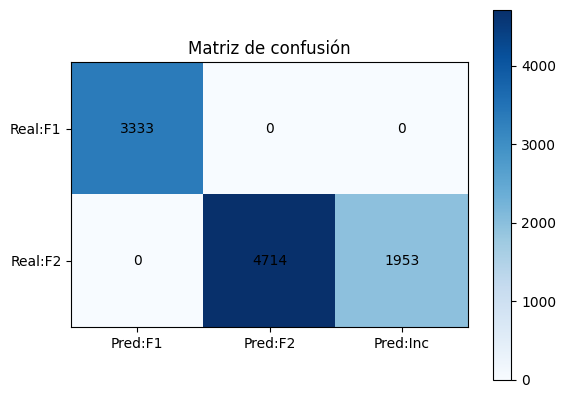

In [7]:
# Construcción y visualización de la matriz de confusión (incluye 'inconcluso')
# La matriz tiene forma 2x3: filas = clases reales (F1,F2), columnas = predicciones (F1,F2,Inc)
cm_test = confusion_matrix_inconclusive(params, data_test)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
im = ax.imshow(cm_test, cmap='Blues', origin='upper')
ax.set_xticks([0,1,2])
ax.set_yticks([0,1])
ax.set_xticklabels(["Pred:F1","Pred:F2","Pred:Inc"])
ax.set_yticklabels(["Real:F1","Real:F2"])
for i in range(2):
    for j in range(3):
        ax.text(j, i, int(cm_test[i,j]), ha='center', va='center', color='black')
plt.colorbar(im, ax=ax)
plt.title('Matriz de confusión')
plt.show()